# Massey Ordinals - Ranking Systems EDA

**What is this data?** 196 different computer ranking systems that rank all NCAA teams throughout the season.

**Key systems:** POM (Pomeroy), SAG (Sagarin), RPI, AP (Associated Press), MOR (Morey)

**Why it matters:** Pre-tournament rankings are one of the strongest predictors of tournament success.

**File size:** ~127 MB, 5.7M rows

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_massey_ordinals, load_seeds, load_teams, load_tourney_results

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. Load & Overview

In [2]:
massey = load_massey_ordinals()
print(f"Shape: {massey.shape[0]:,} rows x {massey.shape[1]} columns")
print(f"\nColumns: {massey.columns.tolist()}")
print(f"\nSeasons: {massey['Season'].min()} to {massey['Season'].max()}")
print(f"Ranking Systems: {massey['SystemName'].nunique()}")
print(f"Teams: {massey['TeamID'].nunique()}")
print(f"RankingDayNum range: {massey['RankingDayNum'].min()} to {massey['RankingDayNum'].max()}")
massey.head(10)

Shape: 5,761,702 rows x 5 columns

Columns: ['Season', 'RankingDayNum', 'SystemName', 'TeamID', 'OrdinalRank']

Seasons: 2003 to 2026
Ranking Systems: 196
Teams: 372
RankingDayNum range: 0 to 133


,Season,RankingDayNum,SystemName,TeamID,OrdinalRank
0,2003,35,SEL,1102,159
1,2003,35,SEL,1103,229
2,2003,35,SEL,1104,12
3,2003,35,SEL,1105,314
4,2003,35,SEL,1106,260
5,2003,35,SEL,1107,249
6,2003,35,SEL,1108,228
7,2003,35,SEL,1110,204
8,2003,35,SEL,1111,183
9,2003,35,SEL,1112,26


### How to read this data

| Column | Meaning |
|--------|---------|
| `Season` | Year |
| `RankingDayNum` | Day of season when ranking was published (0-133) |
| `SystemName` | Which ranking system (e.g., POM = Pomeroy) |
| `TeamID` | Team being ranked |
| `OrdinalRank` | The rank (1 = best) |

**DayNum 133** = just before the tournament starts (Selection Sunday). These are the most useful rankings for prediction.

## 2. Ranking Systems Overview

In [3]:
# How many rankings does each system provide?
system_counts = massey.groupby('SystemName').agg(
    num_rankings=('OrdinalRank', 'count'),
    seasons_covered=('Season', 'nunique'),
    first_season=('Season', 'min'),
    last_season=('Season', 'max')
).sort_values('num_rankings', ascending=False)

print(f"Total ranking systems: {len(system_counts)}")
print(f"\nTop 20 systems by volume:")
display(system_counts.head(20))

Total ranking systems: 196

Top 20 systems by volume:


,num_rankings,seasons_covered,first_season,last_season
SystemName,,,,
MOR,148285,24,2003,2026
POM,145794,24,2003,2026
DOK,132498,21,2006,2026
SAG,130371,21,2003,2023
MAS,122192,20,2003,2026
WLK,118822,24,2003,2026
WIL,117547,21,2005,2026
PGH,116283,19,2008,2026
DOL,115984,24,2003,2026


In [4]:
# Which systems have full coverage (all seasons 2003-2025)?
full_coverage = system_counts[system_counts['seasons_covered'] >= 20]
print(f"Systems with 20+ seasons of data: {len(full_coverage)}")
print(full_coverage.index.tolist())

Systems with 20+ seasons of data: 19
['MOR', 'POM', 'DOK', 'SAG', 'MAS', 'WLK', 'WIL', 'DOL', 'COL', 'BIH', 'DUN', 'WOL', 'RTH', 'SEL', 'RPI', 'WOB', 'USA', 'AP', 'DES']


## 3. Pre-Tournament Rankings (DayNum 128-133)

These are the final rankings before March Madness starts — the most predictive snapshot.

In [5]:
# Get the latest ranking per system per team per season
pre_tourney = massey[massey['RankingDayNum'] >= 128]
pre_tourney = pre_tourney.sort_values('RankingDayNum').groupby(
    ['Season', 'SystemName', 'TeamID']
).tail(1)

print(f"Pre-tournament rankings: {len(pre_tourney):,} rows")
print(f"Systems with pre-tourney data: {pre_tourney['SystemName'].nunique()}")
pre_tourney.head(10)

Pre-tournament rankings: 424,183 rows
Systems with pre-tourney data: 186


,Season,RankingDayNum,SystemName,TeamID,OrdinalRank
5544618,2025,128,USA,1228,25
5526764,2025,128,AP,1266,25
5526760,2025,128,AP,1228,24
5243148,2024,128,USA,1450,25
5243131,2024,128,USA,1173,24
5243140,2024,128,USA,1305,22
388571,2005,128,AP,1150,25
388586,2005,128,AP,1338,22
388581,2005,128,AP,1305,24
394697,2005,128,USA,1150,24


## 4. Key Systems Deep Dive

Focusing on the most well-known and respected systems.

In [6]:
# Key systems to focus on
key_systems = ['POM', 'SAG', 'RPI', 'MOR', 'AP', 'USA', 'SEL', 'WLK', 'WOB', 'DOL']
available_key = [s for s in key_systems if s in massey['SystemName'].unique()]
print(f"Available key systems: {available_key}")

# Get pre-tourney rankings for key systems
key_rankings = pre_tourney[pre_tourney['SystemName'].isin(available_key)]
print(f"\nKey system pre-tourney rankings: {len(key_rankings):,} rows")

Available key systems: ['POM', 'SAG', 'RPI', 'MOR', 'AP', 'USA', 'SEL', 'WLK', 'WOB', 'DOL']

Key system pre-tourney rankings: 60,755 rows


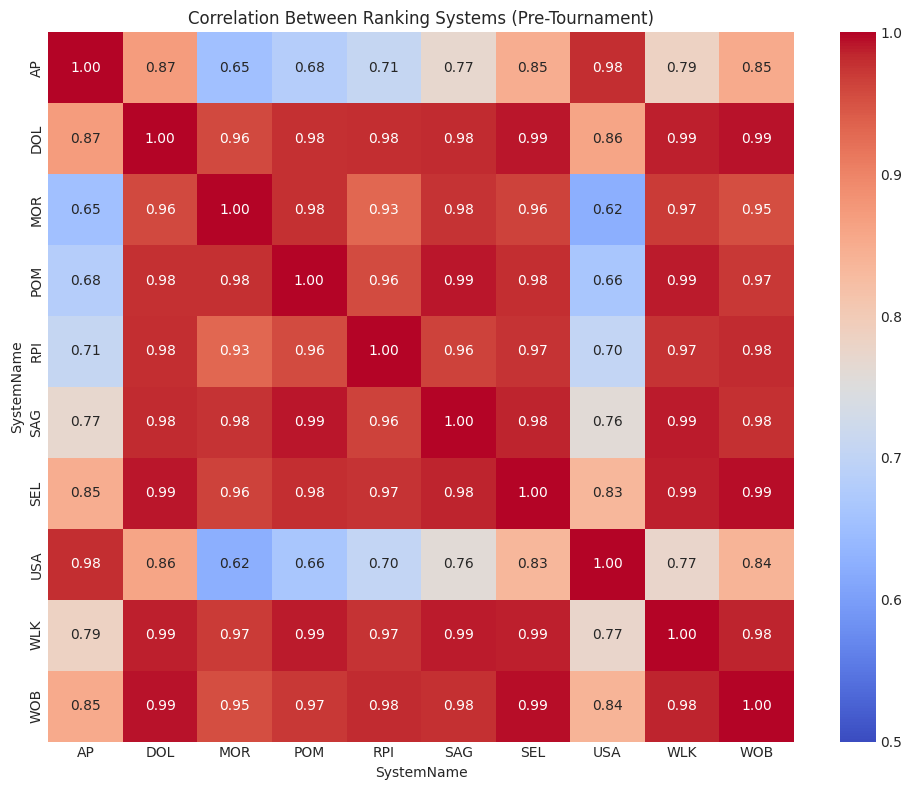

High correlation = systems agree on team rankings
These systems can be averaged into a composite rank.


In [7]:
# How correlated are the key systems with each other?
# Pivot: rows = (Season, TeamID), columns = SystemName, values = OrdinalRank
key_pivot = key_rankings.pivot_table(
    index=['Season', 'TeamID'],
    columns='SystemName',
    values='OrdinalRank'
)

# Correlation between ranking systems
fig, ax = plt.subplots(figsize=(10, 8))
corr = key_pivot.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=0.5, vmax=1, ax=ax)
ax.set_title('Correlation Between Ranking Systems (Pre-Tournament)')
plt.tight_layout()
plt.show()

print("High correlation = systems agree on team rankings")
print("These systems can be averaged into a composite rank.")

## 5. Rankings vs Tournament Seeds

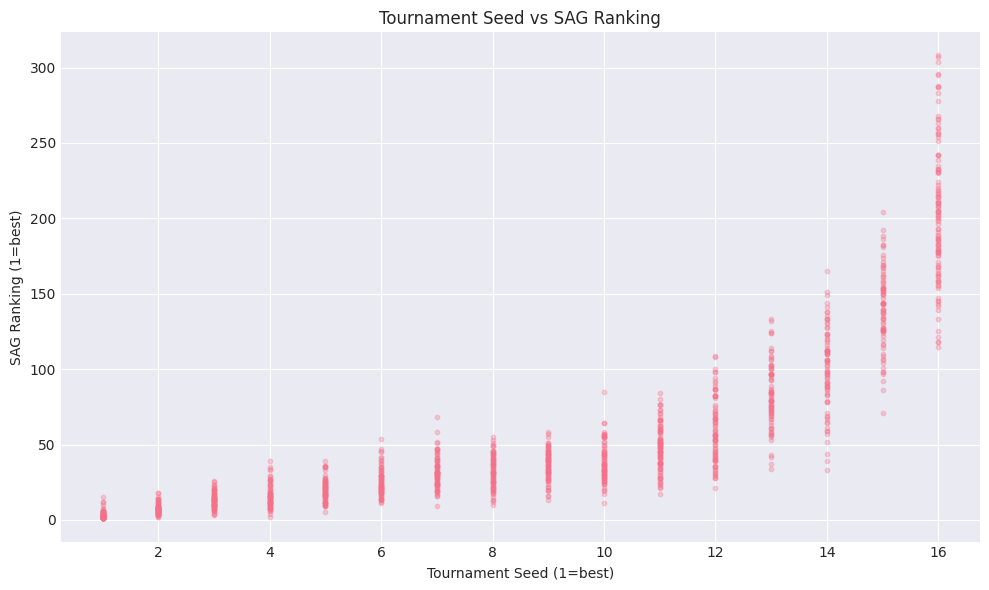

Correlation between seed and SAG rank: 0.817

High correlation = ranking system aligns with tournament committee
But disagreements (off-diagonal) = where rankings add extra info!


In [ ]:
# Load seeds and merge with rankings
seeds = load_seeds('M')
seeds['SeedNum'] = seeds['Seed'].str[1:3].astype(int)

# Use POM (Pomeroy) as example - widely respected
pom_system = 'POM' if 'POM' in available_key else available_key[0]
pom_ranks = pre_tourney[pre_tourney['SystemName'] == pom_system]

# Merge rankings with seeds
seed_rank = seeds.merge(pom_ranks, on=['Season', 'TeamID'], how='inner')

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(seed_rank['SeedNum'], seed_rank['OrdinalRank'], alpha=0.3, s=10)
ax.set_xlabel('Tournament Seed (1=best)')
ax.set_ylabel(f'{pom_system} Ranking (1=best)')
ax.set_title(f'Tournament Seed vs {pom_system} Ranking')
plt.tight_layout()
plt.show()

print(f"Correlation between seed and {pom_system} rank: {seed_rank['SeedNum'].corr(seed_rank['OrdinalRank']):.3f}")
print("\nHigh correlation = ranking system aligns with tournament committee")
print("But disagreements (off-diagonal) = where rankings add extra info!")

## 6. Rankings vs Tournament Outcomes

In [22]:
# Load tournament results
tourney = load_tourney_results('M')
teams = load_teams('M')
team_lookup = dict(zip(teams['TeamID'], teams['TeamName']))

# Merge winner and loser rankings
pom_tourney = tourney.merge(
    pom_ranks[['Season', 'TeamID', 'OrdinalRank']],
    left_on=['Season', 'WTeamID'],
    right_on=['Season', 'TeamID']
).merge(
    pom_ranks[['Season', 'TeamID', 'OrdinalRank']],
    left_on=['Season', 'LTeamID'],
    right_on=['Season', 'TeamID'],
    suffixes=('_W', '_L')
)

# Did the better-ranked team win?
pom_tourney['better_ranked_won'] = pom_tourney['OrdinalRank_W'] < pom_tourney['OrdinalRank_L']

accuracy = pom_tourney['better_ranked_won'].mean()
print(f"{pom_system} ranking accuracy in tournament: {accuracy:.1%}")
print(f"({pom_tourney['better_ranked_won'].sum()}/{len(pom_tourney)} games the better-ranked team won)")

SAG ranking accuracy in tournament: 70.5%
(927/1315 games the better-ranked team won)


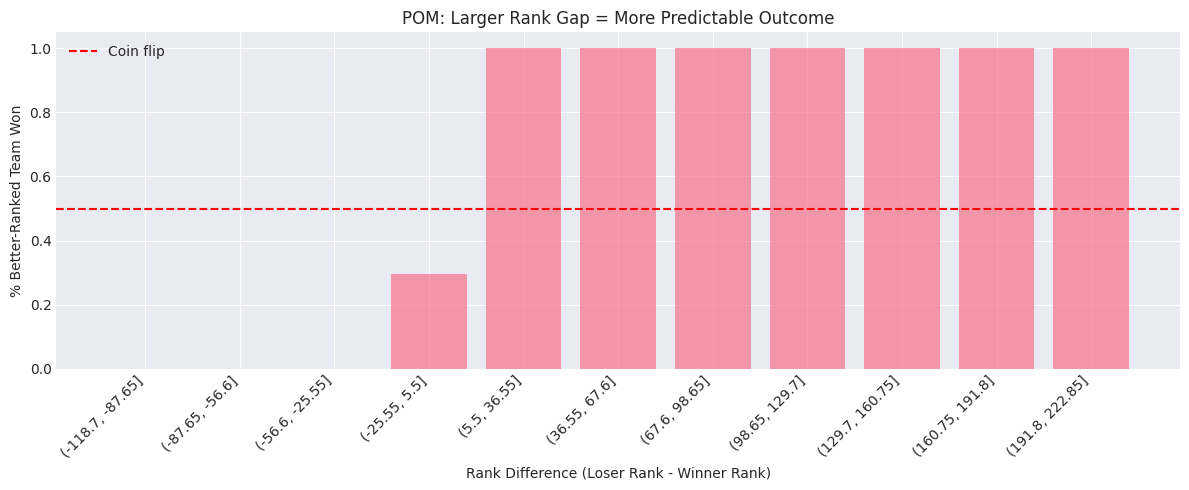

In [13]:
# Rank difference vs upset rate
pom_tourney['rank_diff'] = pom_tourney['OrdinalRank_L'] - pom_tourney['OrdinalRank_W']
pom_tourney['rank_diff_bin'] = pd.cut(pom_tourney['rank_diff'], bins=20)

upset_by_diff = pom_tourney.groupby('rank_diff_bin')['better_ranked_won'].agg(['mean', 'count'])
upset_by_diff = upset_by_diff[upset_by_diff['count'] >= 10]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(upset_by_diff)), upset_by_diff['mean'], alpha=0.7)
ax.set_xticks(range(len(upset_by_diff)))
ax.set_xticklabels([str(x) for x in upset_by_diff.index], rotation=45, ha='right')
ax.set_xlabel('Rank Difference (Loser Rank - Winner Rank)')
ax.set_ylabel('% Better-Ranked Team Won')
ax.set_title(f'{pom_system}: Larger Rank Gap = More Predictable Outcome')
ax.axhline(y=0.5, color='red', linestyle='--', label='Coin flip')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Composite Ranking

Averaging multiple systems is often better than any single system.

In [14]:
# Create composite rank from all available pre-tourney systems
composite = pre_tourney.groupby(['Season', 'TeamID']).agg(
    avg_rank=('OrdinalRank', 'mean'),
    median_rank=('OrdinalRank', 'median'),
    num_systems=('SystemName', 'count')
).reset_index()

print(f"Composite rankings: {len(composite):,} team-seasons")
print(f"\nSample (2025 top 10):")
top_2025 = composite[composite['Season'] == 2025].sort_values('avg_rank').head(10)
top_2025['TeamName'] = top_2025['TeamID'].map(team_lookup)
display(top_2025[['Season', 'TeamID', 'TeamName', 'avg_rank', 'median_rank', 'num_systems']])

Composite rankings: 7,980 team-seasons

Sample (2025 top 10):


,Season,TeamID,TeamName,avg_rank,median_rank,num_systems
7690,2025,1181,Duke,2.214286,2.0,56
7633,2025,1120,Auburn,2.321429,2.0,56
7705,2025,1196,Florida,2.642857,3.0,56
7729,2025,1222,Houston,3.339286,3.0,56
7619,2025,1104,Alabama,5.553571,5.0,56
7899,2025,1397,Tennessee,5.803571,6.0,56
7784,2025,1277,Michigan St,8.482143,7.5,56
7887,2025,1385,St John's,9.142857,8.0,56
7905,2025,1403,Texas Tech,12.339286,10.0,56
7775,2025,1268,Maryland,13.125000,12.0,56


In [15]:
# Compare composite vs single system accuracy in tournament
composite_tourney = tourney.merge(
    composite, left_on=['Season', 'WTeamID'], right_on=['Season', 'TeamID']
).merge(
    composite, left_on=['Season', 'LTeamID'], right_on=['Season', 'TeamID'],
    suffixes=('_W', '_L')
)

composite_tourney['better_ranked_won'] = composite_tourney['avg_rank_W'] < composite_tourney['avg_rank_L']

composite_acc = composite_tourney['better_ranked_won'].mean()
print(f"Composite ranking accuracy: {composite_acc:.1%}")
print(f"Single system ({pom_system}) accuracy: {accuracy:.1%}")
print(f"\nDifference: {(composite_acc - accuracy)*100:+.1f} percentage points")

Composite ranking accuracy: 71.0%
Single system (POM) accuracy: 71.4%

Difference: -0.4 percentage points


## 8. 2026 Rankings Preview

In [16]:
# Check 2026 data availability
massey_2026 = massey[massey['Season'] == 2026]
print(f"2026 rankings: {len(massey_2026):,} rows")
print(f"Systems: {massey_2026['SystemName'].nunique()}")
print(f"Latest DayNum: {massey_2026['RankingDayNum'].max()}")

if len(massey_2026) > 0:
    # Latest composite for 2026
    latest_2026 = massey_2026.sort_values('RankingDayNum').groupby(
        ['SystemName', 'TeamID']
    ).tail(1)
    
    composite_2026 = latest_2026.groupby('TeamID').agg(
        avg_rank=('OrdinalRank', 'mean'),
        num_systems=('SystemName', 'count')
    ).sort_values('avg_rank').head(25)
    
    composite_2026['TeamName'] = composite_2026.index.map(team_lookup)
    print(f"\n2026 Top 25 (Composite):")
    display(composite_2026)
else:
    print("No 2026 data available yet.")

2026 rankings: 195,909 rows
Systems: 56
Latest DayNum: 93

2026 Top 25 (Composite):


,avg_rank,num_systems,TeamName
TeamID,,,
1112,1.785714,56,Arizona
1276,1.982143,56,Michigan
1181,2.839286,56,Duke
1163,6.232143,56,Connecticut
1235,6.678571,56,Iowa St
1228,6.946429,56,Illinois
1222,7.892857,56,Houston
1211,7.928571,56,Gonzaga
1277,9.482143,56,Michigan St


## Key Takeaways

1. **Ranking systems available:**
   - POM, RPI , SAG, MOR some of the good ranking system but there needs to be a small composite list of ranking that are much better

2. **Predictive power:**
   - They are good as they can 70% tell you the correct predicition

3. **Composite vs single system:**
   - I selected 3-4 ranking system can give the most accurate results for 2026

4. **For feature engineering:**
   - Use pre-tournament (DayNum 128-133) rankings
   - Composite average rank across all systems
   - Rank differential between matchup teams
   - Consider using top systems individually (POM, SAG) as separate features